In [1]:
import os
import shutil
import tempfile
import numpy as np
import csv

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from monai import transforms
from monai.apps import DecathlonDataset
from monai.config import print_config
from monai.data import DataLoader, Dataset, CacheDataset, GridPatchDataset, PatchIter
from monai.utils import first, set_determinism
from monai.data.utils import pad_list_data_collate
from torch.amp import GradScaler, autocast
from torch.nn import L1Loss
from tqdm import tqdm

from monai.inferers import LatentDiffusionInferer
from monai.losses import PatchAdversarialLoss, PerceptualLoss
from monai.networks.nets import AutoencoderKL, DiffusionModelUNet, PatchDiscriminator
from monai.networks.schedulers import DDPMScheduler

#print_config()

## Patch-Based Latent Diffusion Model

In [ ]:
#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [3]:
# for reproducibility purposes set a seed
set_determinism(0)

## Using Final_ADC_Dataset

3D ADC volumes (225,225,225)

In [ ]:
train_csv = os.path.join(ROOT_DIR, "AnoDiffExperiments/data_splits_lists/Final_ADC_dataset/train.csv")
train_images_path = []

with open(train_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):
        #print(line)
        train_images_path.append(ROOT_DIR+line[0])

val_csv = os.path.join(ROOT_DIR, "AnoDiffExperiments/data_splits_lists/Final_ADC_dataset/val.csv")
val_images_path = []

with open(val_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):

        val_images_path.append(ROOT_DIR+line[0])

test_reconstruction_csv = os.path.join(ROOT_DIR, "AnoDiffExperiments/data_splits_lists/Final_ADC_dataset/test.csv")
test_reconstruction_images_path = []

with open(test_reconstruction_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):

        test_reconstruction_images_path.append(ROOT_DIR+line[0])


1636it [00:00, 355999.03it/s]
204it [00:00, 86384.45it/s]
205it [00:00, 167968.81it/s]


In [ ]:
#train_datalist = sorted(train_images_path)
train_datalist = train_images_path

#val_datalist = sorted(val_images_path)
val_datalist = val_images_path

#val_datalist = sorted(val_images_path)
test_reconstruction_datalist = test_reconstruction_images_path


batch_size = 48 # 91 Gb vram
num_workers = 4


In [63]:
class SetBackgroundToZero(transforms.Transform):
    """
    Custom MONAI transform that zeros out voxels with the most frequent intensity value.
    
    Args:
        keys (str or list): Keys of the dictionary to apply the transform to.
        tolerance (int): Optional range around the mode value to also zero.
    """
    def __init__(self, tolerance: int = 0):
        super().__init__()
        self.tolerance = tolerance

    def __call__(self, data):
        
            
        is_tensor = isinstance(data, torch.Tensor)
        data_np = data.cpu().numpy() if is_tensor else data

        # Flatten and compute histogram
        flat = data_np.flatten()
        unique, counts = np.unique(flat, return_counts=True)
        mode_val = unique[np.argmax(counts)]

        # Apply tolerance if specified
        if self.tolerance > 0:
            mask = np.isin(data_np, range(mode_val - self.tolerance, mode_val + self.tolerance + 1))
        else:
            mask = data_np == mode_val

        # Zero out the background
        data_np[mask] = 0

        # Put back in original type
        data = torch.from_numpy(data_np) if is_tensor else data_np

        return data

In [64]:
IMAGE_SIZE = 225
PATCH_SIZE = 64

In [65]:

train_transforms = transforms.Compose(
    [
        transforms.LoadImage(),
        transforms.EnsureChannelFirst(),
        transforms.RandAffine(prob=0.2, rotate_range=(0.10, 0.10, 0.10), lazy=True),#+- 0.10 radians for each axis
        transforms.RandScaleCrop(roi_scale=0.9, max_roi_scale=1.1, random_size=True, lazy=True),
        transforms.ResizeWithPadOrCrop(spatial_size=(IMAGE_SIZE, IMAGE_SIZE, IMAGE_SIZE), lazy=True),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=4000.0, b_min=0.0, b_max=1.0, clip=True),
        transforms.RandScaleIntensity(factors=0.15),
        SetBackgroundToZero(),
        transforms.RandSpatialCrop(roi_size=(PATCH_SIZE, PATCH_SIZE, PATCH_SIZE)), # <-----
    ]
)

train_ds = CacheDataset(data=train_datalist, transform=train_transforms)
train_loader = DataLoader(
    #collate_fn=pad_list_data_collate: any tensors are centrally padded to match the shape of the biggest tensor in each dimension
    train_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True, collate_fn=pad_list_data_collate
)

Loading dataset: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1636/1636 [06:00<00:00,  4.54it/s]


Sinon: pas utiliser GridPatchDataset mais juste mettre un random crop en transform train 

et à l'inférence prendre slidingwindowinferer

In [66]:

val_transforms = transforms.Compose(
    [
        transforms.LoadImage(),
        transforms.EnsureChannelFirst(),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=4000.0, b_min=0.0, b_max=1.0, clip=True),
        transforms.Resize(spatial_size=(128,128,128)),
        transforms.ResizeWithPadOrCrop(spatial_size=(128,128,128), lazy=True),
        SetBackgroundToZero(),
        transforms.RandSpatialCrop(roi_size=(PATCH_SIZE, PATCH_SIZE, PATCH_SIZE)), # <-----
    ]
)
val_ds = CacheDataset(data=val_datalist, transform=val_transforms)
val_loader = DataLoader(
    val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True
)

Loading dataset: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 204/204 [01:11<00:00,  2.84it/s]


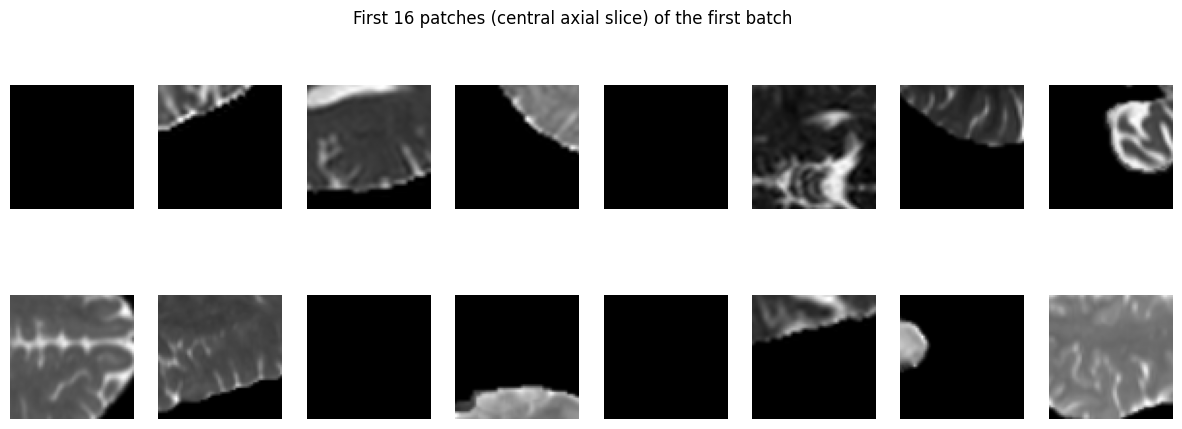

In [67]:
# Visualize the first few items from train_loader
for i, batch in enumerate(train_loader):       
    if i >= 1:  # Show first 6 items
        break

    # Display the 16 first patches of the first batch
    fig, axs = plt.subplots(2, 8, figsize=(15, 5))
    for j in range(16):
        patch = batch[j, 0].cpu().numpy() 

        axs[j // 8, j % 8].imshow(patch[:, :, patch.shape[2] // 2], cmap="gray")
        axs[j // 8, j % 8].axis("off")

    plt.suptitle("First 16 patches (central axial slice) of the first batch")
    plt.show()

## Autoencoder KL

### Define Autoencoder KL network

In this section, we will define an autoencoder with KL-regularization for the LDM. The autoencoder's primary purpose is to transform input images into a latent representation that the diffusion model will subsequently learn. By doing so, we can decrease the computational resources required to train the diffusion component, making this approach suitable for learning high-resolution medical images.


In [68]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

Using cuda


In [69]:
autoencoder = AutoencoderKL(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(32, 64, 64),
    latent_channels=3,
    num_res_blocks=1,
    norm_num_groups=16,
    attention_levels=(False, False, True),
)
autoencoder.to(device)


discriminator = PatchDiscriminator(spatial_dims=3, num_layers_d=3, channels=32, in_channels=1, out_channels=1)
discriminator.to(device)

PatchDiscriminator(
  (initial_conv): Convolution(
    (conv): Conv3d(1, 32, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1))
    (adn): ADN(
      (D): Dropout(p=0.0, inplace=False)
      (A): LeakyReLU(negative_slope=0.2)
    )
  )
  (0): Convolution(
    (conv): Conv3d(32, 64, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (adn): ADN(
      (N): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (D): Dropout(p=0.0, inplace=False)
      (A): LeakyReLU(negative_slope=0.2)
    )
  )
  (1): Convolution(
    (conv): Conv3d(64, 128, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (adn): ADN(
      (N): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (D): Dropout(p=0.0, inplace=False)
      (A): LeakyReLU(negative_slope=0.2)
    )
  )
  (2): Convolution(
    (conv): Conv3d(128, 256, kernel_size=(4, 4, 4), stride=(1, 1, 1), padding=(1, 1, 1), bias=Fal

### Defining Losses

We will also specify the perceptual and adversarial losses, including the involved networks, and the optimizers to use during the training process.

In [70]:
l1_loss = L1Loss()
adv_loss = PatchAdversarialLoss(criterion="least_squares")
loss_perceptual = PerceptualLoss(spatial_dims=3, network_type="squeeze", is_fake_3d=True, fake_3d_ratio=0.2)
loss_perceptual.to(device)


def kl_loss(z_mu, z_sigma):
    klloss = 0.5 * torch.sum(z_mu.pow(2) + z_sigma.pow(2) - torch.log(z_sigma.pow(2)) - 1, dim=[1, 2, 3, 4])
    return torch.sum(klloss) / klloss.shape[0]


adv_weight = 0.01
perceptual_weight = 0.001
kl_weight = 1e-6

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.


In [71]:
optimizer_g = torch.optim.Adam(params=autoencoder.parameters(), lr=1e-4)
optimizer_d = torch.optim.Adam(params=discriminator.parameters(), lr=1e-4)

### Train model

In [72]:
max_epochs = 1000
autoencoder_warm_up_n_epochs = 5
val_interval = 10
epoch_recon_loss_list = []
epoch_gen_loss_list = []
epoch_disc_loss_list = []
val_recon_epoch_loss_list = []
intermediary_images = []
n_example_images = 4

for epoch in range(max_epochs):
    autoencoder.train()
    discriminator.train()
    epoch_loss = 0
    gen_epoch_loss = 0
    disc_epoch_loss = 0
    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), ncols=110)
    progress_bar.set_description(f"Epoch {epoch}")
    for step, batch in progress_bar:
        images = batch.to(device)  # choose only one of Brats channels

        # Generator part
        optimizer_g.zero_grad(set_to_none=True)
        reconstruction, z_mu, z_sigma = autoencoder(images)
        klloss = kl_loss(z_mu, z_sigma)

        recons_loss = l1_loss(reconstruction.float(), images.float())
        p_loss = loss_perceptual(reconstruction.float(), images.float())
        loss_g = recons_loss + kl_weight * klloss + perceptual_weight * p_loss

        if epoch > autoencoder_warm_up_n_epochs:
            logits_fake = discriminator(reconstruction.contiguous().float())[-1]
            generator_loss = adv_loss(logits_fake, target_is_real=True, for_discriminator=False)
            loss_g += adv_weight * generator_loss

        loss_g.backward()
        optimizer_g.step()

        if epoch > autoencoder_warm_up_n_epochs:
            # Discriminator part
            optimizer_d.zero_grad(set_to_none=True)
            logits_fake = discriminator(reconstruction.contiguous().detach())[-1]
            loss_d_fake = adv_loss(logits_fake, target_is_real=False, for_discriminator=True)
            logits_real = discriminator(images.contiguous().detach())[-1]
            loss_d_real = adv_loss(logits_real, target_is_real=True, for_discriminator=True)
            discriminator_loss = (loss_d_fake + loss_d_real) * 0.5

            loss_d = adv_weight * discriminator_loss

            loss_d.backward()
            optimizer_d.step()

        epoch_loss += recons_loss.item()
        if epoch > autoencoder_warm_up_n_epochs:
            gen_epoch_loss += generator_loss.item()
            disc_epoch_loss += discriminator_loss.item()

        progress_bar.set_postfix(
            {
                "recons_loss": epoch_loss / (step + 1),
                "gen_loss": gen_epoch_loss / (step + 1),
                "disc_loss": disc_epoch_loss / (step + 1),
            }
        )
    epoch_recon_loss_list.append(epoch_loss / (step + 1))
    epoch_gen_loss_list.append(gen_epoch_loss / (step + 1))
    epoch_disc_loss_list.append(disc_epoch_loss / (step + 1))

del discriminator
del loss_perceptual
torch.cuda.empty_cache()

Epoch 24:  46%|█████▉       | 16/35 [01:26<01:43,  5.43s/it, recons_loss=0.02, gen_loss=0.38, disc_loss=0.242]


KeyboardInterrupt: 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


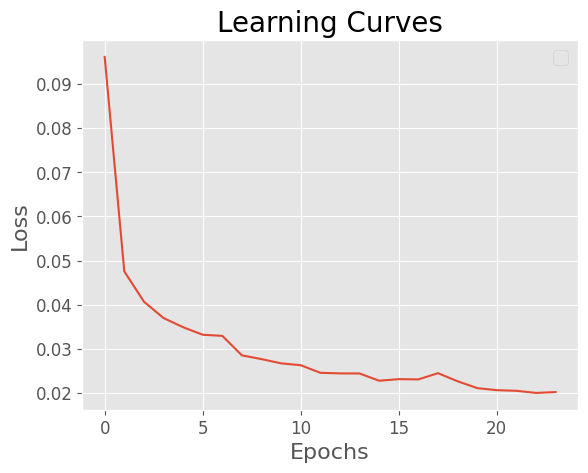

In [73]:
plt.style.use("ggplot")
plt.title("Learning Curves", fontsize=20)
plt.plot(epoch_recon_loss_list)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("Epochs", fontsize=16)
plt.ylabel("Loss", fontsize=16)
plt.legend(prop={"size": 14})
plt.show()

#### **Where is the validation ? Is it done by the generator and discriminator?**

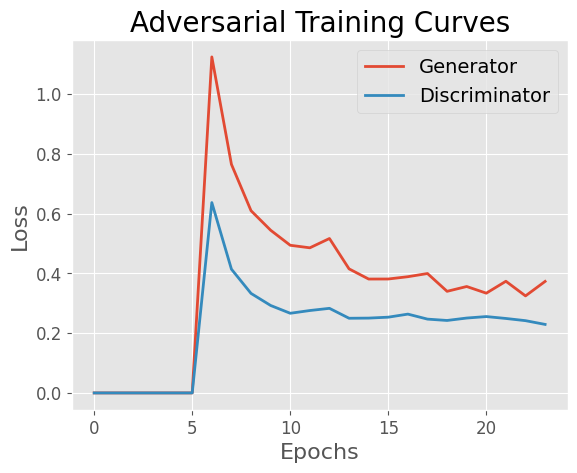

In [74]:
plt.title("Adversarial Training Curves", fontsize=20)
plt.plot(epoch_gen_loss_list, color="C0", linewidth=2.0, label="Generator")
plt.plot(epoch_disc_loss_list, color="C1", linewidth=2.0, label="Discriminator")
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("Epochs", fontsize=16)
plt.ylabel("Loss", fontsize=16)
plt.legend(prop={"size": 14})
plt.show()

### Visualise reconstructions

In [76]:
reconstruction.shape

torch.Size([48, 1, 64, 64, 64])

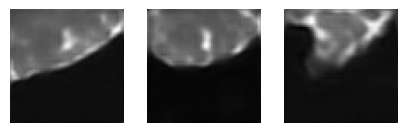

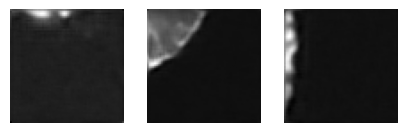

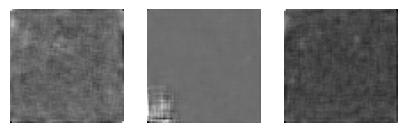

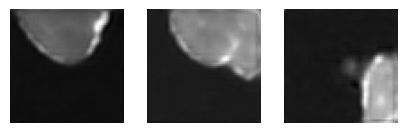

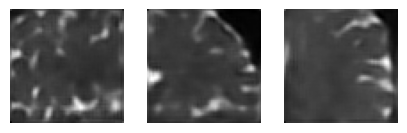

In [80]:
# Plot axial, coronal and sagittal slices of a training sample
for idx in range(5):
    img = reconstruction[idx, 0].detach().cpu().numpy()
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(5, 3))
    for ax in axs:
        ax.axis("off")
    ax = axs[0]
    ax.imshow(img[..., img.shape[2] // 2], cmap="gray")
    ax = axs[1]
    ax.imshow(img[:, img.shape[1] // 2, ...], cmap="gray")
    ax = axs[2]
    ax.imshow(img[img.shape[0] // 2, ...], cmap="gray")

**Faire une slidingwindow pour voir a quoi ça ressemble avec l'image en entier**